# Gradient Descent on House Prices Dataset

          0
0  0.396564
1  0.502405
2  0.571134
3  0.402062
4  0.396564 x values
          0
0  1.000000
1  0.909091
2  0.909091
3  0.906061
4  0.836364 yvalues

[0.52141034] coef
[-0.00104236] intercept


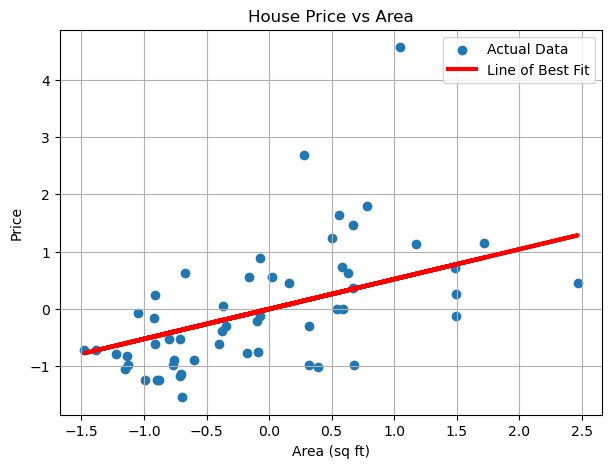

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv("Housing.csv")


X = df[["area"]]    
y = df[["price"]]


scaler = MinMaxScaler()

X_normalized = X.copy()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized)

print(X_normalized.head(),"x values")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler = MinMaxScaler()
Y_normalized = y.copy()
Y_normalized = scaler.fit_transform(y)
Y_normalized = pd.DataFrame(Y_normalized)

print(Y_normalized.head(),"yvalues")

scaler = StandardScaler()
Y_scaled = scaler.fit_transform(y)

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.1, random_state=1
)

model = LinearRegression()
model.fit(x_train, y_train)


print()



# x_sorted = x_train.sort_values(by="area")
y_line = model.predict(x_test)


print(model.coef_[0],"coef")

print(model.intercept_,"intercept")

plt.figure(figsize=(7,5))
plt.scatter(x_test, y_test, label="Actual Data")
plt.plot(x_test, y_line,color ="red",linewidth=3, label="Line of Best Fit")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("House Price vs Area")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler


df = pd.read_csv("Housing.csv")

df = df.dropna()

X = df[["area"]]
y = df[["price"]]


scaler = MinMaxScaler()
X_normalized = X.copy()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized)
Y_normalized = y.copy()
Y_normalized = scaler.fit_transform(y)
Y_normalized = pd.DataFrame(Y_normalized)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
Y_scaled = scaler.fit_transform(y)

# X_scaled = pd.DataFrame(X_scaled).values()
# Y_scaled = pd.DataFrame(Y_scaled).values()

# print(X_scaled,"xscaled")
# print(Y_scaled,"Y_scaled")

m = 0.0
learning_rate = 0.01
iters = 1000
loss_list = []
n = len(X)

for i in range(iters):
    y_pred = m * X_scaled
    error  = y_pred - Y_scaled
    loss   = np.mean(error**2)
    loss_list.append(loss)
    dm = (2/n) * np.sum(error * X_scaled)
    m  = m - learning_rate * dm
    # print(f"Iter {i}: m={m:.4f}, loss={loss:.2f}")

print(m,"final m")
    

0.5359973448760139 final m
